In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px
from microboone_utils import *
from file import File

In [2]:
f = File("/nevis/westside/data/sc5303/Data/ubOpen/h5/bnb_WithWire_00.h5")

In [3]:
startevt = 10
nevts = 100 #anything from 0 to len(f)

In [4]:
tables = ['event_table','particle_table']

In [16]:
for t in tables: f.add_group(t)
f.read_data(startevt, len(f))

In [17]:
len(f)

1085

In [18]:
events = f.get_dataframe_evt('event_table')
parts = f.get_dataframe_evt('particle_table')

In [30]:
len(events['evt_idx'].unique())

1075

In [25]:
len(parts['evt_idx'].unique())

874

In [13]:
parts['evt_idx'].unique()

array([ 10,  11,  13,  14,  15,  16,  18,  20,  21,  22,  24,  25,  26,
        28,  29,  30,  31,  32,  33,  34,  35,  36,  38,  39,  40,  41,
        42,  43,  44,  45,  46,  47,  48,  49,  50,  52,  53,  54,  55,
        56,  58,  59,  60,  62,  63,  64,  65,  66,  68,  69,  70,  71,
        72,  73,  74,  75,  76,  78,  79,  80,  82,  84,  85,  86,  87,
        88,  89,  90,  91,  92,  93,  94,  97,  98,  99, 100, 102, 103,
       104, 105, 106, 107, 108, 109])

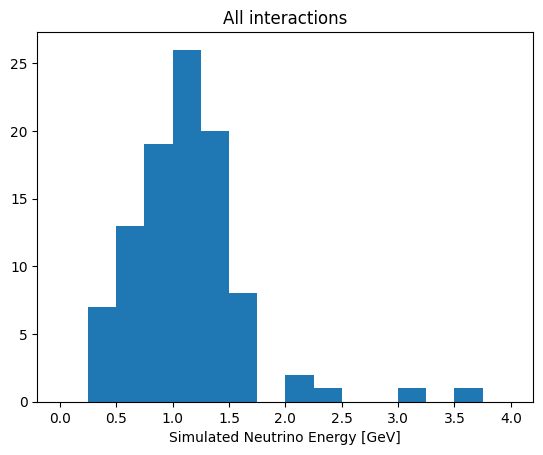

In [15]:
plt.hist(events['nu_energy'],bins=np.linspace(0,4,17))
plt.xlabel('Simulated Neutrino Energy [GeV]')
plt.title('All interactions')
plt.show()

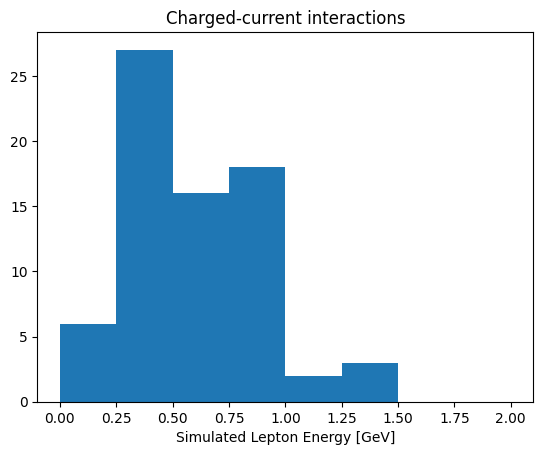

In [16]:
plt.hist(events.query('is_cc==1')['lep_energy'],bins=np.linspace(0,2,9))
plt.xlabel('Simulated Lepton Energy [GeV]')
plt.title('Charged-current interactions')
plt.show()

More detailed information of the simulated particles can be extracted from the particle table

In [ ]:
primaries = parts[parts['start_process']==b'primary']

In [34]:
parts['start_process'].unique()

array([b'primary', b'hIoni', b'neutronInelastic', b'muIoni',
       b'muMinusCaptureAtRest', b'nCapture', b'eBrem', b'eIoni', b'phot',
       b'compt', b'conv', b'annihil', b'pi+Inelastic', b'hadElastic',
       b'protonInelastic', b'Decay', b'pi-Inelastic', b'CoulombScat',
       b'hBertiniCaptureAtRest'], dtype='|S64')

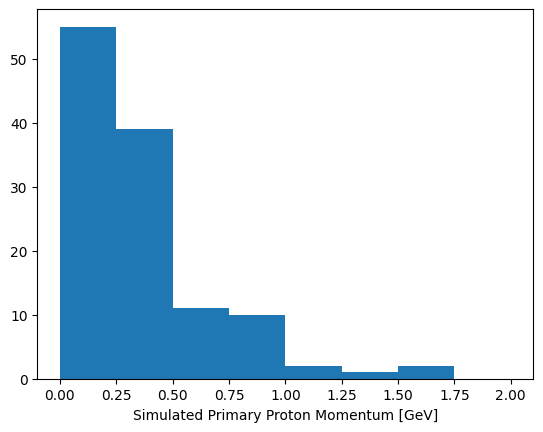

In [28]:
plt.hist(primaries.query('g4_pdg==2212')['momentum'],bins=np.linspace(0,2,9))
plt.xlabel('Simulated Primary Proton Momentum [GeV]')
plt.show()

We can compute the proton multiplicity by counting the number of protons in each event as follows

In [ ]:
nprotons_p03 = primaries.query('g4_pdg==2212 and momentum>0.3').groupby(["evt_idx"]).size().reset_index().rename(columns={0:'nprotons_p03'})
events = events.merge(nprotons_p03, on=["evt_idx"], how="left")
events.fillna(0, inplace=True)

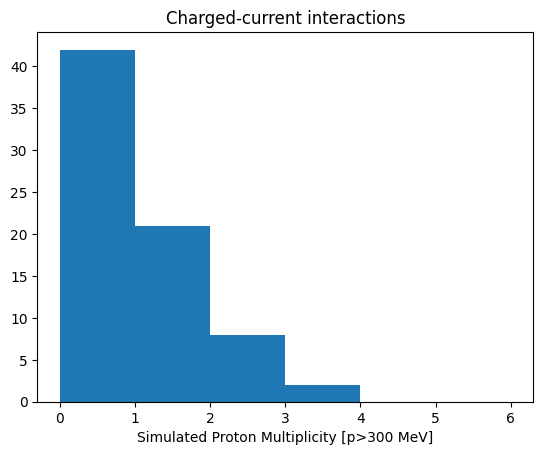

In [30]:
plt.hist(events.query('is_cc==1')['nprotons_p03'],bins=np.linspace(0,6,7))
plt.xlabel('Simulated Proton Multiplicity [p>300 MeV]')
plt.title('Charged-current interactions')
plt.show()